<a href="https://colab.research.google.com/github/meghanjukl-meg/ICTK_Exit/blob/main/Exit_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##  Section A
Data Wrangling & Exploratory Analysis

###Q1

In [211]:
#loading dataset
bh_data = pd.read_csv('/content/Bengaluru_House_Data.csv')
bh_data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [212]:
#basic info datatypes
bh_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [213]:
#shape
bh_data.shape

(13320, 9)

In [214]:
bh_data.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [215]:
#a) dropping rows with missing location or size
bh_data.dropna(subset=['location', 'size'], inplace=True)
bh_data.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
society,5499
total_sqft,0
bath,57
balcony,593
price,0


In [216]:
bh_data['society'].nunique()

2676

In [217]:
bh_data = bh_data.drop(columns=['society'])
bh_data.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,57
balcony,593
price,0


In [218]:
# (b) filling missing bath and balcony values with their column medians.
bh_data['bath'].fillna(bh_data['bath'].median(), inplace=True)
bh_data['balcony'].fillna(bh_data['balcony'].median(), inplace=True)

/tmp/ipykernel_1752/3092309019.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bh_data['bath'].fillna(bh_data['bath'].median(), inplace=True)
/tmp/ipykernel_1752/3092309019.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [219]:
#verifying
bh_data.shape

(13303, 8)

In [220]:
bh_data[['bath','balcony']].isnull().sum()

,0
bath,0
balcony,0


###Q2

In [221]:
#Extract only the numeric part and store it as a new integer column called bhk.
bh_data['bhk']= bh_data['size'].apply(lambda x: int(x.split(' ')[0]))
bh_data['bhk']

,bhk
0,2
1,4
2,3
3,3
4,2
...,...
13315,5
13316,4
13317,2
13318,4


In [222]:
bh_data = bh_data.drop(columns=['size'])
bh_data.head()

,area_type,availability,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,19-Dec,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Ready To Move,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Ready To Move,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Ready To Move,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Ready To Move,Kothanur,1200,2.0,1.0,51.00,2


In [223]:
bh_data['availability'].nunique()

80

In [224]:
#handling total_sqft
def convert_range_to_num(x):
  temp = x.split('-')
  if len(temp) == 2:
    return (float(temp[0]) + float(temp[1]))/2
  try:
    return float(x)
  except:
    return None

In [225]:
bh_data['total_sqft'] = bh_data['total_sqft'].apply(convert_range_to_num)
bh_data['total_sqft']

,total_sqft
0,1056.0
1,2600.0
2,1440.0
3,1521.0
4,1200.0
...,...
13315,3453.0
13316,3600.0
13317,1141.0
13318,4689.0


In [226]:
bh_data=bh_data.dropna(subset=['total_sqft'])

In [227]:
bh_data.dtypes

,0
area_type,object
availability,object
location,object
total_sqft,float64
bath,float64
balcony,float64
price,float64
bhk,int64


### Q3

In [228]:
#new feature
bh_data['price_per_sqft'] = bh_data['price']*100000/bh_data['total_sqft']
bh_data['price_per_sqft']

,price_per_sqft
0,3699.810606
1,4615.384615
2,4305.555556
3,6245.890861
4,4250.000000
...,...
13315,6689.834926
13316,11111.111111
13317,5258.545136
13318,10407.336319


In [229]:
#remove outliers per location
def remove_outliers(data):
    df_out = pd.DataFrame()
    for key, subdf in data.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        # Filter: Keep rows within Mean +/- 3*SD
        reduced_df = subdf[(subdf.price_per_sqft > (m - 3*st)) & (subdf.price_per_sqft <= (m + 3*st))]
        df_out = pd.concat([df_out, reduced_df], ignore_index=True)
    return df_out

In [230]:
#tracking
initial =len(bh_data)
bh_data=remove_outliers(bh_data)
removed = initial - len(bh_data)
removed

638

In [231]:
print(f"No of rows removed :{removed}")

No of rows removed :638


In [232]:
#bh_data= bh_data[bh_data['price_per_sqft'] <= 25000]

In [233]:
print(bh_data['price_per_sqft'].max())

2300000.0


Real estate price are highly depended on neighborhood rather than standalone. A global threshold will delete luxury properties as outlier

#### Q4 : Visualisation

In [234]:
import seaborn as sns

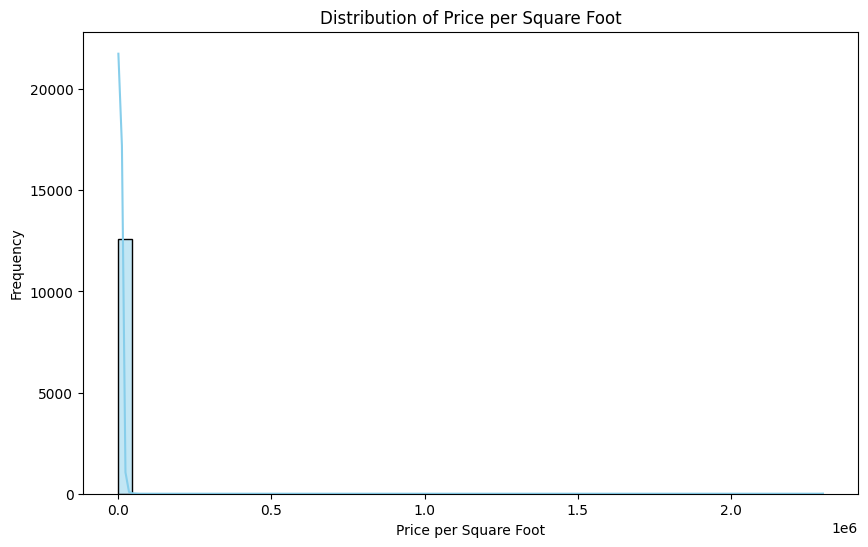

In [235]:
#Distribution of price_per_sqft(histogram + KDE overlay)
plt.figure(figsize=(10, 6))
sns.histplot(bh_data['price_per_sqft'], kde=True, bins=50,color='skyblue')
plt.xlabel('Price per Square Foot')
plt.title('Distribution of Price per Square Foot')
plt.ylabel('Frequency')
#plt.xlim(0,20000)
plt.show()

the distribution is right skewed ,there might be properties with high price

In [236]:
bh_data.dtypes

,0
area_type,object
availability,object
location,object
total_sqft,float64
bath,float64
balcony,float64
price,float64
bhk,int64
price_per_sqft,float64


In [237]:
numeric_columns = bh_data.select_dtypes(include=['int64', 'float64']).columns

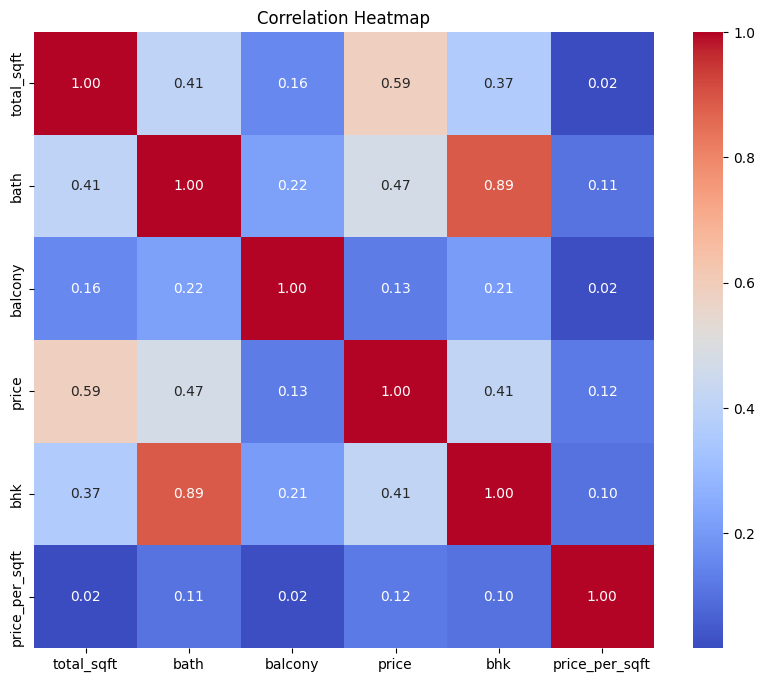

In [238]:
plt.figure(figsize=(10,8))
sns.heatmap(bh_data[numeric_columns].corr(), annot=True, fmt=".2f",cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Insight:ery strong positive correlation (0.89) between bhk and bath.total_sqft has the strongest correlation with price (0.59), confirming that physical area is a primary driver of cost in this dataset.

Text(0.5, 1.0, 'Price distribution across BHK category')

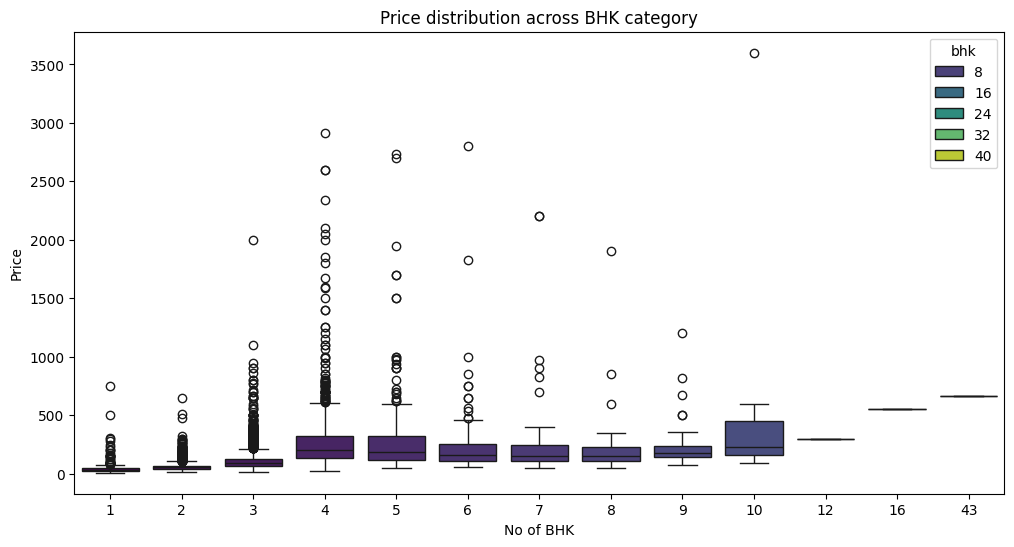

In [239]:
#Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(x='bhk', y='price', data=bh_data,hue='bhk',palette='viridis')
plt.xlabel('No of BHK')
plt.ylabel('Price')
plt.title('Price distribution across BHK category')

median price generally increases as the number of BHK increases, but there is significant overlap and high variance, particularly in the 3 to 5 BHK range

### Q5: Encoding


In [240]:
from sklearn.preprocessing import LabelEncoder,MinMaxScaler

In [241]:
# bh_area = pd.get_dummies(bh_data['area_type'], prefix='area')
# bh_data = pd.concat([bh_data, bh_area], axis=1)

In [242]:
# area type
bh_data = pd.get_dummies(bh_data,columns=['area_type'],prefix= 'area',dtype= int)
bh_data.head()

,availability,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,area_Built-up Area,area_Carpet Area,area_Plot Area,area_Super built-up Area
0,Ready To Move,1st Block BEL Layout,1540.0,3.0,2.0,85.0,3,5519.480519,0,0,0,1
1,Ready To Move,1st Block BEL Layout,1800.0,5.0,1.0,250.0,4,13888.888889,1,0,0,0
2,Ready To Move,1st Block HBR Layout,2500.0,6.0,3.0,500.0,5,20000.000000,0,0,1,0
3,Ready To Move,1st Block HBR Layout,600.0,1.0,0.0,45.0,1,7500.000000,0,0,0,1
4,Ready To Move,1st Block HBR Layout,3150.0,4.0,2.0,150.0,4,4761.904762,1,0,0,0


In [243]:
#location
top_20_locations = bh_data['location'].value_counts().nlargest(20).index

# Map locations not in top 20 to 'Other'
bh_data['location'] = bh_data['location'].apply(lambda x: x if x in top_20_locations else 'Other')


In [244]:
bh_data['location']

,location
0,Other
1,Other
2,Other
3,Other
4,Other
...,...
12614,Other
12615,Other
12616,Other
12617,Other


In [245]:
bh_data['location'].nunique()

21

In [246]:
le = LabelEncoder()
bh_data['location'] = le.fit_transform(bh_data['location'])

In [247]:
print(f"Unique locations after mapping: {bh_data['location'].nunique()}")
print(bh_data.head())

Unique locations after mapping: 21
    availability  location  total_sqft  bath  balcony  price  bhk  \
0  Ready To Move        13      1540.0   3.0      2.0   85.0    3   
1  Ready To Move        13      1800.0   5.0      1.0  250.0    4   
2  Ready To Move        13      2500.0   6.0      3.0  500.0    5   
3  Ready To Move        13       600.0   1.0      0.0   45.0    1   
4  Ready To Move        13      3150.0   4.0      2.0  150.0    4   

   price_per_sqft  area_Built-up  Area  area_Carpet  Area  area_Plot  Area  \
0     5519.480519                    0                  0                0   
1    13888.888889                    1                  0                0   
2    20000.000000                    0                  0                1   
3     7500.000000                    0                  0                0   
4     4761.904762                    1                  0                0   

   area_Super built-up  Area  
0                          1  
1                  

In [248]:
scaler = MinMaxScaler()
bh_data[['total_sqft','bath']] = scaler.fit_transform(bh_data[['total_sqft','bath']])

In [249]:
print(bh_data[['total_sqft','bath']].describe().loc[['min','max']])

     total_sqft  bath
min         0.0   0.0
max         1.0   1.0


**area_type** is a nominal categorical variable with low cardinality (only 4 unique values)therefore One-hot encoding allows the model to treat each category as a distinct feature

**location** Grouping infrequent locations into "Other" and applying Label Encoding captures the most impactful local trends

**total_sqft and bath**  Scaling them to a 0–1 range ensures that the model doesn't unfairly weight the larger numbers.


In [250]:
bh_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12619 entries, 0 to 12618
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   availability               12619 non-null  object 
 1   location                   12619 non-null  int64  
 2   total_sqft                 12619 non-null  float64
 3   bath                       12619 non-null  float64
 4   balcony                    12619 non-null  float64
 5   price                      12619 non-null  float64
 6   bhk                        12619 non-null  int64  
 7   price_per_sqft             12619 non-null  float64
 8   area_Built-up  Area        12619 non-null  int64  
 9   area_Carpet  Area          12619 non-null  int64  
 10  area_Plot  Area            12619 non-null  int64  
 11  area_Super built-up  Area  12619 non-null  int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 1.2+ MB


In [251]:
#simplifying availability col : if ready to move 1 else 0
bh_data['availability'] = bh_data['availability'].apply(lambda x: 1 if x == 'Ready To Move' else 0)

##  Section B
Supervised Learning

###Q6

In [252]:
#training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score

In [253]:
X= bh_data.drop(['price','price_per_sqft'],axis=1)
y=bh_data['price']

droping price_per_sqft since it is a derived quantity and might cause data leakage

In [254]:
#80/20
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

In [255]:
#linear Reg
lr_model = LinearRegression()
lr_model.fit(X_train,y_train)

LinearRegression()

In [256]:
#predict
y_pred = lr_model.predict(X_test)

In [257]:
#Metrics
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [258]:
print(f"Linear Regression Results:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R-squared: {r2:.4f}")

Linear Regression Results:
RMSE: 110.68
MAE: 41.72
R-squared: 0.1817


Linear Regression model is struggling with this dataset. An R-squared of 0.1817 means the model only explains about 18% of the variation in house prices

In [259]:
#Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
#predict
y_pred = ridge_model.predict(X_test)
#Metrics
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [260]:
print(f"Ridge Regression Results:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R-squared: {r2:.4f}")

Ridge Regression Results:
RMSE: 105.60
MAE: 42.36
R-squared: 0.2551


In [261]:
#Lasso
lasso_m = Ridge(alpha=1.0)
lasso_m.fit(X_train, y_train)
#predict
y_pred = lasso_m.predict(X_test)
#Metrics
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [262]:
print(f"Lasso Regression Results:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R-squared: {r2:.4f}")

Lasso Regression Results:
RMSE: 105.60
MAE: 42.36
R-squared: 0.2551


both Ridge and Lasso provided a significant boost over your base Linear Regression, increasing the R-squared from 0.1817 to 0.2551

In [263]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1)
}
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R-squared": r2_score(y_test, y_pred)
    })

print(pd.DataFrame(results).round(4))

    Model      RMSE      MAE  R-squared
0  Linear  110.6837  41.7171     0.1817
1   Ridge  105.6005  42.3627     0.2551
2   Lasso  108.8046  41.6154     0.2092


Regularisation is beneficila since it address multicolinearity (bhk,bath,total_sqft),helps to focus more onbroder trends and understand the encoded locations

Q7. Binary classification target: high_value = 1 if price >= 100 lakhs, else 0.

In [264]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,classification_report

In [265]:
#target
bh_data['high_value'] = (bh_data['price'] >= 100).astype(int)
bh_data['high_value']

,high_value
0,0
1,1
2,1
3,0
4,1
...,...
12614,1
12615,0
12616,0
12617,0


In [266]:
X = bh_data.drop(['price', 'price_per_sqft', 'high_value'], axis=1)
y = bh_data['high_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [267]:
from sklearn.naive_bayes import GaussianNB

In [268]:
log_reg = LogisticRegression(max_iter=1000).fit(X_train, y_train)
nb_model = GaussianNB().fit(X_train, y_train)

In [269]:
for name, model in [("Logistic Regression", log_reg), ("Naive Bayes", nb_model)]:
    preds = model.predict(X_test)
    print(f"\n{name}:")
    print(f"Accuracy: {accuracy_score(y_test, preds):.2f}")
    print(f"Precision: {precision_score(y_test, preds):.2f}")
    print(f"Recall: {recall_score(y_test, preds):.2f}")
    print(f"F1-Score: {f1_score(y_test, preds):.2f}")


Logistic Regression:
Accuracy: 0.83
Precision: 0.88
Recall: 0.50
F1-Score: 0.64

Naive Bayes:
Accuracy: 0.86
Precision: 0.81
Recall: 0.69
F1-Score: 0.74


here naive bayes is better performing than logistic but logistic is more precise .
Naive Bayes has beter balance between precision and recall

In [270]:
#Confusion matrix for better prdicting
cm = confusion_matrix(y_test, nb_model.predict(X_test))
cm

array([[1633,  124],
       [ 241,  526]])

### Q8

In [271]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [272]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print('Accuracy',accuracy_score(y_test,y_pred_rf))
print('Precision',precision_score(y_test,y_pred_rf))
print('Recall',recall_score(y_test,y_pred_rf))
print('f1_score',f1_score(y_test,y_pred_rf))

Accuracy 0.8878763866877971
Precision 0.8184210526315789
Recall 0.8109517601043025
f1_score 0.8146692861820564


In [273]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

In [274]:
#grid search
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [275]:
best_rf = grid_search.best_estimator_
print(f"Best Params: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

Best Params: {'max_depth': 10, 'n_estimators': 50}
Best CV Score: 0.8253


In [276]:
y_pred_rf = best_rf.predict(X_test)

In [277]:
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"Test F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

Test Accuracy: 0.8926
Test Precision: 0.8221
Test Recall: 0.8253
Test F1-Score: 0.8237


<Axes: title={'center': 'Feature Importances'}>

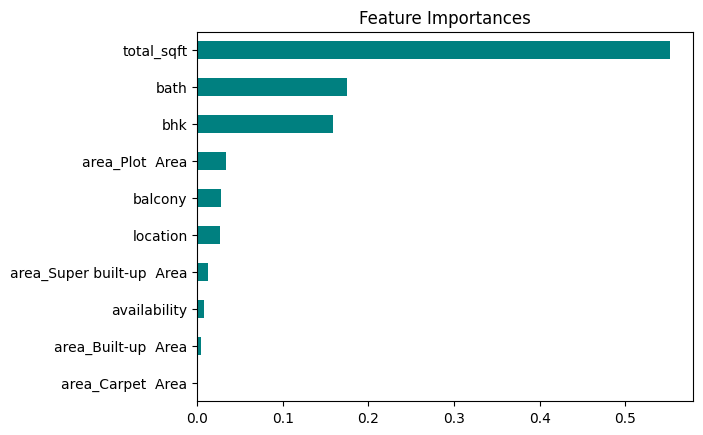

In [278]:
best_rf = grid_search.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', color='teal', title='Feature Importances')

total_sqft remains the dominant predictor, contributing nearly 50% to the decision-making process.

 ## Section C
Unsupervised Learning & Dimensionality Reduction

###Q9

In [279]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [280]:
#scaling
features = ['total_sqft', 'bath', 'price_per_sqft']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bh_data[features])

In [281]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
bh_data['cluster'] = kmeans.fit_predict(X_scaled)

In [282]:
WCSS =[]
for i in range(2,10):
  k_m = KMeans(n_clusters= i, init='k-means++',random_state=42)
  k_m.fit(X_scaled)
  WCSS.append(k_m.inertia_)

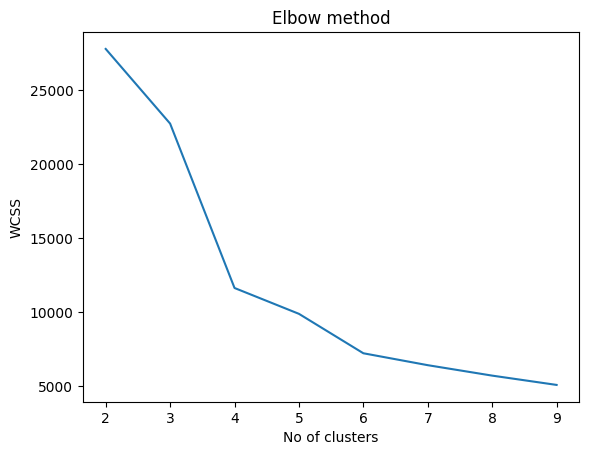

In [283]:
import matplotlib.pyplot as plt
plt.plot(range(2,10),WCSS)
plt.title('Elbow method')
plt.xlabel("No of clusters")
plt.ylabel('WCSS')
plt.show()

k=4

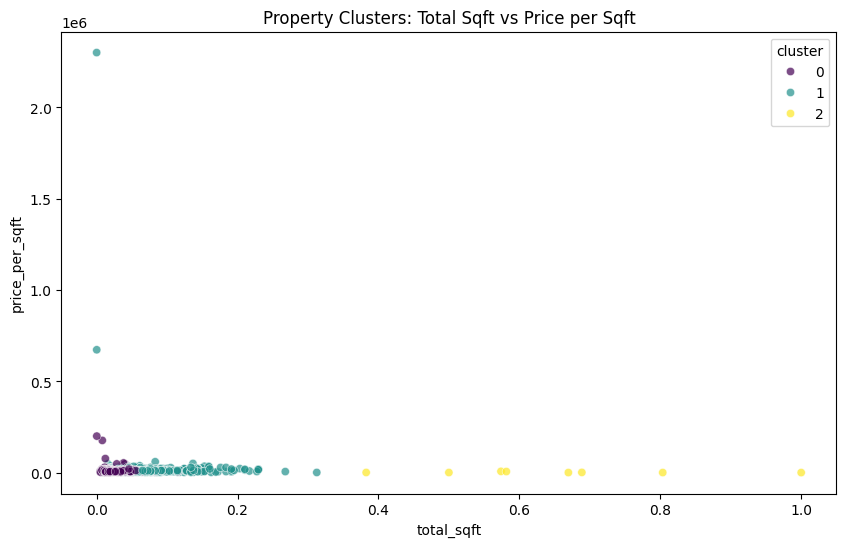

In [284]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_sqft', y='price_per_sqft', hue='cluster',
                data=bh_data, palette='viridis', alpha=0.7)
plt.title('Property Clusters: Total Sqft vs Price per Sqft')
plt.show()

to get a better cluster  clipping

/tmp/ipykernel_1752/1337287619.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bh_data_clean['cluster'] = kmeans.fit_predict(X_scaled)


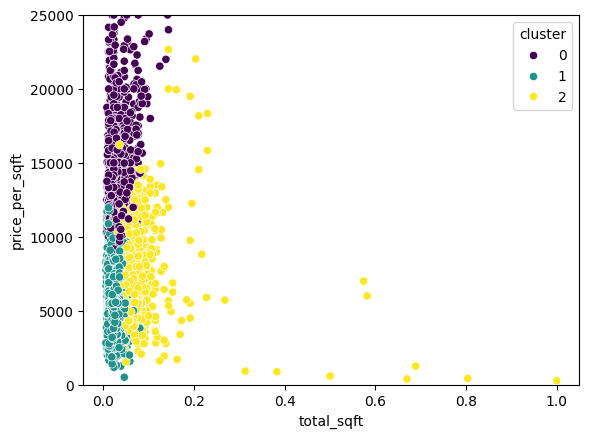

In [285]:
bh_data_clean = bh_data[bh_data['price_per_sqft'] <= 25000]

scaler = StandardScaler()
features = ['total_sqft', 'bath', 'price_per_sqft']
X_scaled = scaler.fit_transform(bh_data_clean[features])

kmeans = KMeans(n_clusters=3, random_state=42)
bh_data_clean['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Re-plot
sns.scatterplot(x='total_sqft', y='price_per_sqft', hue='cluster', data=bh_data_clean, palette='viridis')
plt.ylim(0, 25000) # Zoom in to see the 'hill' of the data
plt.show()

Cluster 0 (Purple) — The "Premium/Luxury" Segment:
Profile: Moderate in size, but with a very high price_per_sqft

Cluster 1 (Teal) — The "Budget/Entry-Level" Segment:
Profile: These properties have the lowest price_per_sqft (mostly below ₹10,000) and very small total_sqft

Cluster 2 (Yellow) — The "Spacious/Large Estates" Segment:
Profile: These have a moderate price_per_sqft but dominate the right side of the graph with higher total_sqft.

###Q10

In [286]:
from sklearn.decomposition import PCA

In [287]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_train) # Using scaled X from previous steps

# 2. Retrain on Top 5 Components
pca_5 = PCA(n_components=5)
X_train_pca5 = pca_5.fit_transform(X_train)
X_test_pca5 = pca_5.transform(X_test)

best_rf_pca = RandomForestClassifier(n_estimators=200, random_state=42)
best_rf_pca.fit(X_train_pca5, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [288]:
# Report Results
print(classification_report(y_test, best_rf_pca.predict(X_test_pca5)))

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1757
           1       0.79      0.77      0.78       767

    accuracy                           0.87      2524
   macro avg       0.84      0.84      0.84      2524
weighted avg       0.87      0.87      0.87      2524

